# Trabalho de Probabilidade e Estatística: Saúde Mental de Adolescentes




## Objetivo
Este notebook consolida todas as etapas da Análise Exploratória de Dados (EDA) do nosso projeto. Ele engloba as análises estatísticas individuais, estatísticas descritivas unificadas, testes de integridade, boxplots e o estudo de matriz de correlações.

In [1]:
# Célula de configuração automática para rodar no Google Colab
import os

# Verifica se estamos rodando no Google Colab
if 'COLAB_RELEASE_TAG' in os.environ or 'COLAB_GPU' in os.environ:
    print('Ambiente Google Colab detectado.')
    print('Instalando kagglehub e baixando os dados públicos do Kaggle...')
    os.system('pip install -q kagglehub')
    
    import kagglehub
    import shutil
    
    # Baixa o dataset bruto (que já é nativamente limpo)
    path_kaggle = kagglehub.dataset_download('algozee/teenager-menthal-healy')
    csv_original = os.path.join(path_kaggle, 'Teen_Mental_Health_Dataset.csv')
    
    # Recria a estrutura de pastas esperada pelo notebook
    os.makedirs('./bases/processed', exist_ok=True)
    
    # Copia simulando o resultado final do nosso script de limpeza local
    shutil.copy(csv_original, './bases/processed/dados_limpos.csv')
    print('Dados baixados e configurados com sucesso para o Colab!')
else:
    print('Ambiente local detectado. Lendo arquivos locais normalmente.')

Ambiente local detectado. Lendo arquivos locais normalmente.


***
# Parte 1: Estatísticas Descritivas e Correlações
***

# Análises Complementares — Estatísticas Descritivas, Correlações e Novos Cruzamentos

## 1. Introdução
Este estudo de Análise Exploratória de Dados aborda: **estatísticas descritivas completas**, **boxplots**, **análise formal de correlações** e **cruzamentos de dados**.

### 1.1 Carregamento dos Dados

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

%matplotlib inline

# Configuração global de estilo
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['font.family'] = 'sans-serif'
sns.set_palette('muted')

df = pd.read_csv('./bases/processed/dados_limpos.csv')
print(f'Base carregada: {df.shape[0]} registros, {df.shape[1]} variáveis.')
df.head()

Base carregada: 1200 registros, 13 variáveis.


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


## 2. Estatísticas Descritivas Completas

### 2.1 Variáveis Numéricas
A tabela abaixo apresenta as medidas de **tendência central** (média, mediana, moda), **dispersão** (desvio padrão, variância) e **separatrizes** (Q1, Q2/mediana, Q3) para todas as variáveis numéricas do dataset.

In [3]:
# Estatísticas descritivas completas para variáveis numéricas
numericas = df.select_dtypes(include='number')

descritivas = pd.DataFrame({
    'Média': numericas.mean(),
    'Mediana': numericas.median(),
    'Moda': numericas.mode().iloc[0],
    'Desvio Padrão': numericas.std(),
    'Variância': numericas.var(),
    'Mínimo': numericas.min(),
    'Q1 (25%)': numericas.quantile(0.25),
    'Q2 (50%)': numericas.quantile(0.50),
    'Q3 (75%)': numericas.quantile(0.75),
    'Máximo': numericas.max()
}).round(4)

display(descritivas)

,Média,Mediana,Moda,Desvio Padrão,Variância,Mínimo,Q1 (25%),Q2 (50%),Q3 (75%),Máximo
age,15.9283,16.00,13.00,2.0219,4.0883,13.0,14.0,16.00,18.00,19.0
daily_social_media_hours,4.5367,4.50,3.50,2.0296,4.1193,1.0,2.8,4.50,6.30,8.0
sleep_hours,6.4494,6.50,6.80,1.4427,2.0813,4.0,5.2,6.50,7.60,9.0
screen_time_before_sleep,1.7403,1.80,1.40,0.7167,0.5136,0.5,1.1,1.80,2.40,3.0
academic_performance,2.9904,2.99,2.36,0.5768,0.3326,2.0,2.5,2.99,3.48,4.0
physical_activity,1.0145,1.00,1.90,0.5822,0.3389,0.0,0.5,1.00,1.50,2.0
stress_level,5.4458,5.00,4.00,2.9033,8.4291,1.0,3.0,5.00,8.00,10.0
anxiety_level,5.6367,6.00,6.00,2.8595,8.1765,1.0,3.0,6.00,8.00,10.0
addiction_level,5.5650,6.00,6.00,2.8306,8.0125,1.0,3.0,6.00,8.00,10.0
depression_label,0.0258,0.00,0.00,0.1587,0.0252,0.0,0.0,0.00,0.00,1.0


#### 2.1.1 Interpretação das Estatísticas Descritivas

* **Idade (`age`):** A média de 15.93 anos com desvio padrão de 2.02 indica que a amostra é bem distribuída na faixa de 13 a 19 anos. A mediana (16) está muito próxima da média, sugerindo uma distribuição aproximadamente simétrica.
* **Horas em redes sociais (`daily_social_media_hours`):** Média de 4.54 horas/dia com desvio padrão de 2.03. O Q1 (2.8h) e Q3 (6.3h) mostram que 50% dos adolescentes passam entre ~3 e ~6 horas diárias nas redes, com variância relativamente alta (4.11), indicando perfis de uso bastante heterogêneos.
* **Horas de sono (`sleep_hours`):** Média de 6.45h com desvio padrão de 1.44. O Q1 (5.2h) revela que 25% da amostra dorme menos de 5.2 horas, valor abaixo do recomendado pela OMS para adolescentes (8–10 horas).
* **Métricas de saúde mental (`stress_level`, `anxiety_level`, `addiction_level`):** As três variáveis apresentam médias entre 5.4 e 5.6 na escala 1–10, com desvios padrão altos (~2.8–2.9), o que indica uma distribuição ampla e dispersa dos scores, sem concentração extrema em nenhum ponto.
* **Depressão (`depression_label`):** Média de 0.026 confirma que apenas ~2.6% da amostra possui indicativo de depressão (31 de 1200 registros), tornando esta variável altamente desbalanceada.

### 2.2 Variáveis Categóricas

In [4]:
# Frequências das variáveis categóricas
categoricas = ['gender', 'platform_usage', 'social_interaction_level']

for col in categoricas:
    freq = df[col].value_counts()
    perc = df[col].value_counts(normalize=True).mul(100).round(2)
    tabela = pd.DataFrame({'Frequência': freq, 'Percentual (%)': perc})
    print(f'\n--- {col} ---')
    display(tabela)


--- gender ---


,Frequência,Percentual (%)
gender,,
male,615,51.25
female,585,48.75



--- platform_usage ---


,Frequência,Percentual (%)
platform_usage,,
Instagram,411,34.25
TikTok,398,33.17
Both,391,32.58



--- social_interaction_level ---


,Frequência,Percentual (%)
social_interaction_level,,
medium,416,34.67
low,415,34.58
high,369,30.75


#### 2.2.1 Interpretação das Frequências Categóricas

* **Gênero (`gender`):** A distribuição é equilibrada entre masculino (~51.3%) e feminino (~48.8%), evitando viés de gênero nas análises.
* **Plataforma (`platform_usage`):** As três categorias (Instagram, TikTok, Both) possuem frequências próximas (~33% cada), permitindo comparações entre grupos de tamanho similar.
* **Nível de interação social (`social_interaction_level`):** Distribuição equilibrada entre low, medium e high (~33% cada), o que é positivo para a análise de diferenças entre grupos.

## 3. Boxplots

### 3.1 Comparação das Métricas de Saúde Mental
O boxplot abaixo compara a distribuição das três métricas psicológicas (`stress_level`, `anxiety_level`, `addiction_level`) lado a lado, permitindo visualizar quartis, medianas e a dispersão de cada indicador.

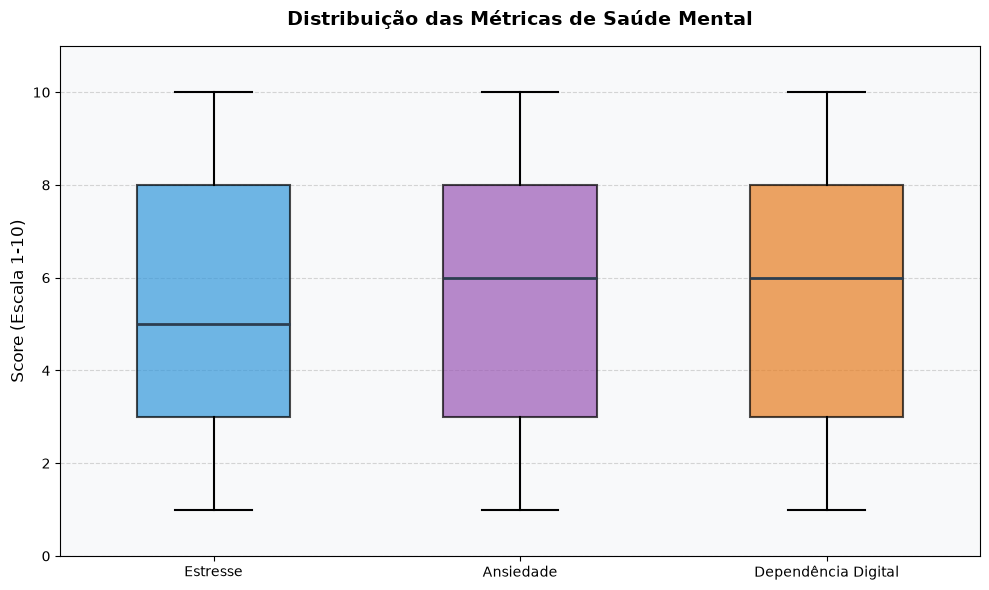

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

dados_box = df[['stress_level', 'anxiety_level', 'addiction_level']]
dados_box.columns = ['Estresse', 'Ansiedade', 'Dependência Digital']

bp = ax.boxplot(
    [dados_box[col] for col in dados_box.columns],
    tick_labels=dados_box.columns,
    patch_artist=True,
    widths=0.5,
    boxprops=dict(linewidth=1.5),
    medianprops=dict(color='#2c3e50', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=5, alpha=0.5)
)

cores = ['#3498db', '#9b59b6', '#e67e22']
for patch, cor in zip(bp['boxes'], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)

ax.set_title('Distribuição das Métricas de Saúde Mental', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Score (Escala 1-10)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_ylim(0, 11)

plt.tight_layout()
plt.show()

#### 3.1.1 Interpretação
* As três métricas apresentam distribuições **muito similares**, com medianas próximas a 5–6 e amplitude interquartil (IQR) abrangendo de ~3 a ~8.
* Nenhuma das três métricas apresenta outliers significativos, indicando que os scores estão distribuídos de forma relativamente uniforme na escala 1–10.
* A simetria das caixas em torno da mediana sugere distribuições aproximadamente uniformes, sem concentração forte em valores extremos.

### 3.2 Nível de Estresse por Gênero

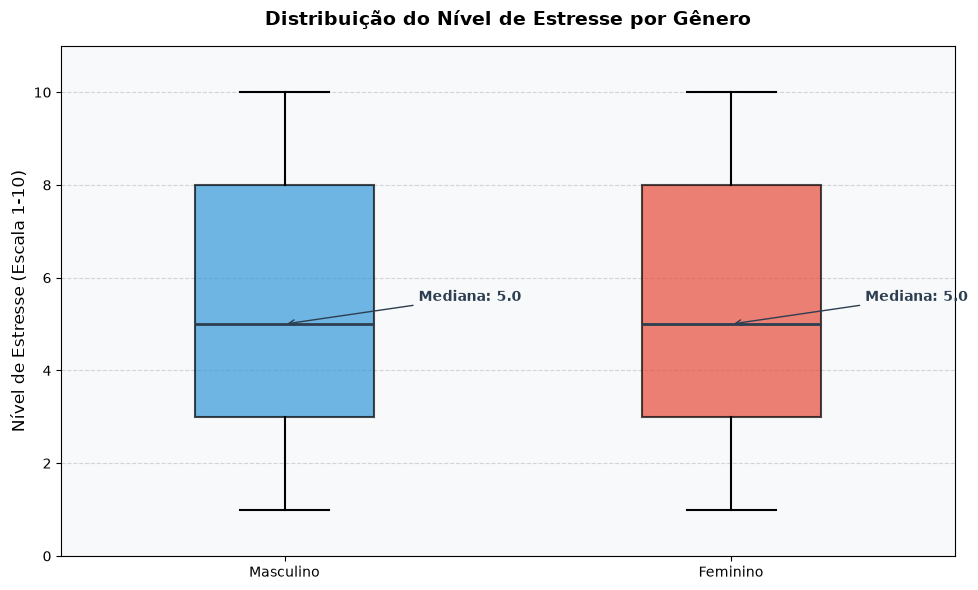


Estatísticas por gênero:


,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
female,585.0,5.42,2.95,1.0,3.0,5.0,8.0,10.0
male,615.0,5.47,2.86,1.0,3.0,5.0,8.0,10.0


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

dados_m = df[df['gender'] == 'male']['stress_level']
dados_f = df[df['gender'] == 'female']['stress_level']

bp = ax.boxplot(
    [dados_m, dados_f],
    tick_labels=['Masculino', 'Feminino'],
    patch_artist=True,
    widths=0.4,
    boxprops=dict(linewidth=1.5),
    medianprops=dict(color='#2c3e50', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5)
)

cores = ['#3498db', '#e74c3c']
for patch, cor in zip(bp['boxes'], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)

# Anotar medianas
for i, dados in enumerate([dados_m, dados_f]):
    med = dados.median()
    ax.annotate(f'Mediana: {med:.1f}', xy=(i+1, med), xytext=(i+1.3, med+0.5),
                fontsize=10, fontweight='bold', color='#2c3e50',
                arrowprops=dict(arrowstyle='->', color='#2c3e50'))

ax.set_title('Distribuição do Nível de Estresse por Gênero', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Nível de Estresse (Escala 1-10)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_ylim(0, 11)

plt.tight_layout()
plt.show()

# Tabela complementar
print('\nEstatísticas por gênero:')
display(df.groupby('gender')['stress_level'].describe().round(2))

#### 3.2.1 Interpretação
* As distribuições de estresse entre gêneros são **muito similares**, com medianas, quartis e amplitudes praticamente idênticas.
* Não há evidência visual de diferença significativa entre os grupos nesta amostra, o que sugere que o gênero isoladamente não é um fator discriminante para o nível de estresse reportado.

## 4. Análise de Correlações Formal

### 4.1 Matriz de Correlação (Heatmap)
A matriz abaixo apresenta os coeficientes de correlação de Pearson entre todas as variáveis numéricas do dataset. Valores próximos de +1 indicam correlação positiva forte, próximos de -1 indicam correlação negativa forte, e próximos de 0 indicam ausência de relação linear.

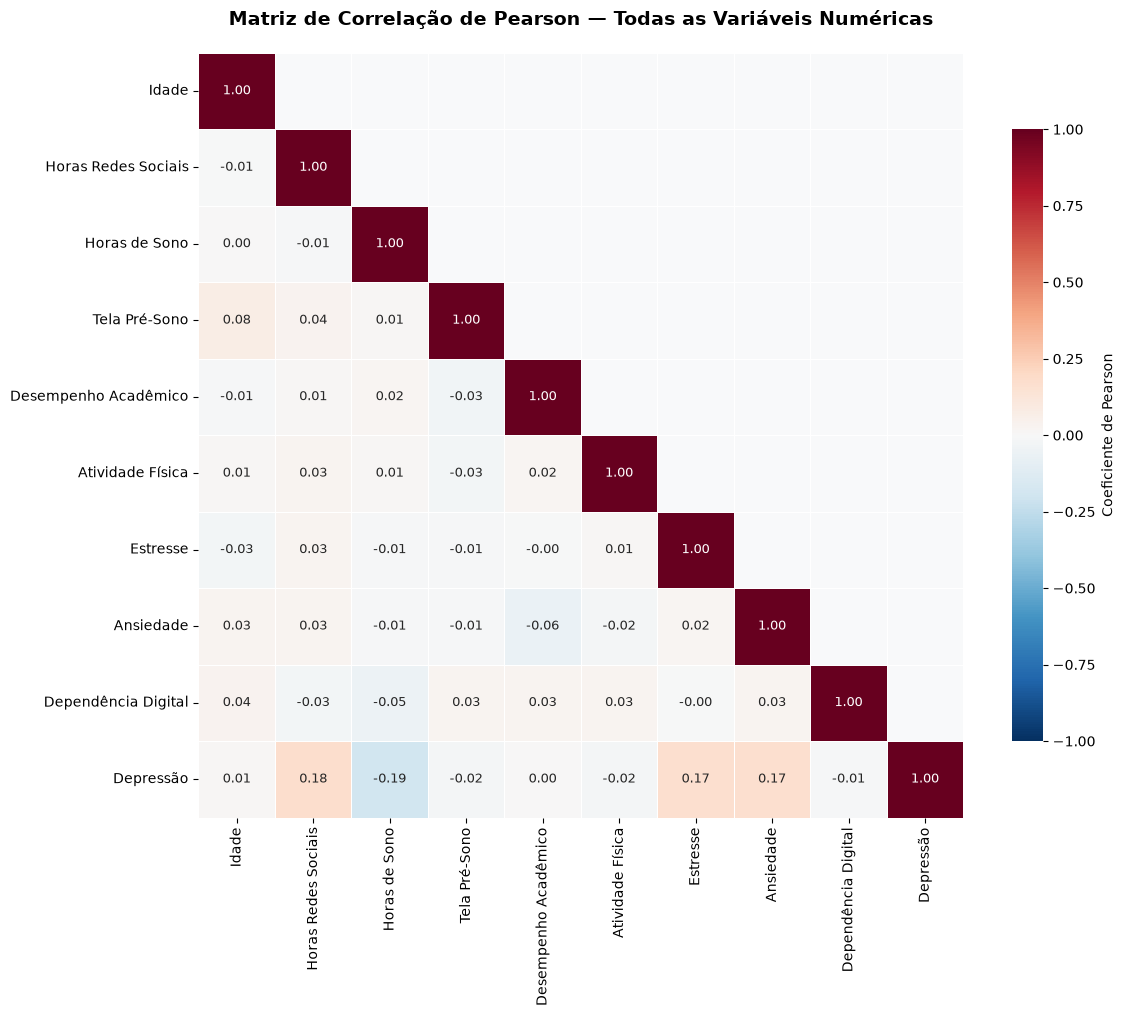

In [7]:
# Heatmap da Matriz de Correlação
corr = df.select_dtypes(include='number').corr().round(4)

fig, ax = plt.subplots(figsize=(12, 10))

# Rótulos em português
rotulos = {
    'age': 'Idade',
    'daily_social_media_hours': 'Horas Redes Sociais',
    'sleep_hours': 'Horas de Sono',
    'screen_time_before_sleep': 'Tela Pré-Sono',
    'academic_performance': 'Desempenho Acadêmico',
    'physical_activity': 'Atividade Física',
    'stress_level': 'Estresse',
    'anxiety_level': 'Ansiedade',
    'addiction_level': 'Dependência Digital',
    'depression_label': 'Depressão'
}

corr_renomeado = corr.rename(index=rotulos, columns=rotulos)

mask = np.triu(np.ones_like(corr_renomeado, dtype=bool), k=1)

sns.heatmap(
    corr_renomeado,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Coeficiente de Pearson', 'shrink': 0.8},
    annot_kws={'size': 9}
)

ax.set_title('Matriz de Correlação de Pearson — Todas as Variáveis Numéricas', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

#### 4.1.1 Interpretação da Matriz
A principal conclusão visual do heatmap é que **não existem correlações fortes** (|r| > 0.5) entre nenhum par de variáveis neste dataset. As correlações mais relevantes, ainda que fracas, convergem todas para a variável `depression_label`:

| Par de Variáveis | r (Pearson) | Interpretação |
|---|---|---|
| Horas de Sono ↔ Depressão | −0.19 | Fraca negativa — menos sono, mais depressão |
| Horas Redes Sociais ↔ Depressão | +0.18 | Fraca positiva — mais uso, mais depressão |
| Estresse ↔ Depressão | +0.17 | Fraca positiva |
| Ansiedade ↔ Depressão | +0.17 | Fraca positiva |

### 4.2 Coeficientes de Pearson e Spearman para os Pares Mais Relevantes
Para os 4 pares com maior correlação absoluta, calculamos tanto o coeficiente de **Pearson** (relações lineares) quanto o de **Spearman** (relações monotônicas), incluindo o **p-valor** para avaliar significância estatística.

In [8]:
# Pares com maior correlação
pares = [
    ('sleep_hours', 'depression_label', 'Horas de Sono ↔ Depressão'),
    ('daily_social_media_hours', 'depression_label', 'Horas Redes Sociais ↔ Depressão'),
    ('stress_level', 'depression_label', 'Estresse ↔ Depressão'),
    ('anxiety_level', 'depression_label', 'Ansiedade ↔ Depressão'),
]

resultados = []
for var1, var2, nome in pares:
    r_pearson, p_pearson = stats.pearsonr(df[var1], df[var2])
    r_spearman, p_spearman = stats.spearmanr(df[var1], df[var2])
    resultados.append({
        'Relação': nome,
        'Pearson (r)': round(r_pearson, 4),
        'p-valor (Pearson)': f'{p_pearson:.2e}',
        'Spearman (ρ)': round(r_spearman, 4),
        'p-valor (Spearman)': f'{p_spearman:.2e}',
        'Significativo (α=0.05)?': '✅ Sim' if p_pearson < 0.05 else '❌ Não'
    })

tabela_corr = pd.DataFrame(resultados)
display(tabela_corr)

,Relação,Pearson (r),p-valor (Pearson),Spearman (ρ),p-valor (Spearman),Significativo (α=0.05)?
0,Horas de Sono ↔ Depressão,-0.1906,2.78e-11,-0.1910,2.54e-11,✅ Sim
1,Horas Redes Sociais ↔ Depressão,0.1752,9.96e-10,0.1752,1.00e-09,✅ Sim
2,Estresse ↔ Depressão,0.1705,2.80e-09,0.1694,3.54e-09,✅ Sim
3,Ansiedade ↔ Depressão,0.1696,3.41e-09,0.1698,3.22e-09,✅ Sim


#### 4.2.1 Interpretação dos Coeficientes
* Todos os 4 pares apresentam **p-valores significativos** (p < 0.05), confirmando que as correlações observadas, embora fracas em magnitude, **não são fruto do acaso**.
* Os coeficientes de **Spearman** são consistentes com os de Pearson, indicando que as relações se mantêm tanto em análise linear quanto monotônica.
* A correlação mais forte da base é **Horas de Sono ↔ Depressão (r ≈ −0.19)**, indicando uma tendência fraca de que adolescentes que dormem menos apresentam maior presença de indicativo de depressão.
* É fundamental ressaltar que **correlação não implica causalidade**: os dados mostram associação estatística, mas não permitem afirmar que dormir pouco *causa* depressão ou que usar redes sociais *causa* depressão.

## 5. Novos Cruzamentos de Dados

### 5.1 Cruzamento 1: Desempenho Acadêmico vs Horas de Sono

#### Introdução
A variável `academic_performance` (desempenho acadêmico medido por GPA, escala 2.0–4.0) não foi explorada em nenhuma análise anterior. A pergunta central é: **adolescentes que dormem mais apresentam melhor desempenho acadêmico?**

**Hipótese:** Espera-se uma correlação positiva fraca entre as duas variáveis, dado que o sono adequado favorece a consolidação da memória e o desempenho cognitivo.

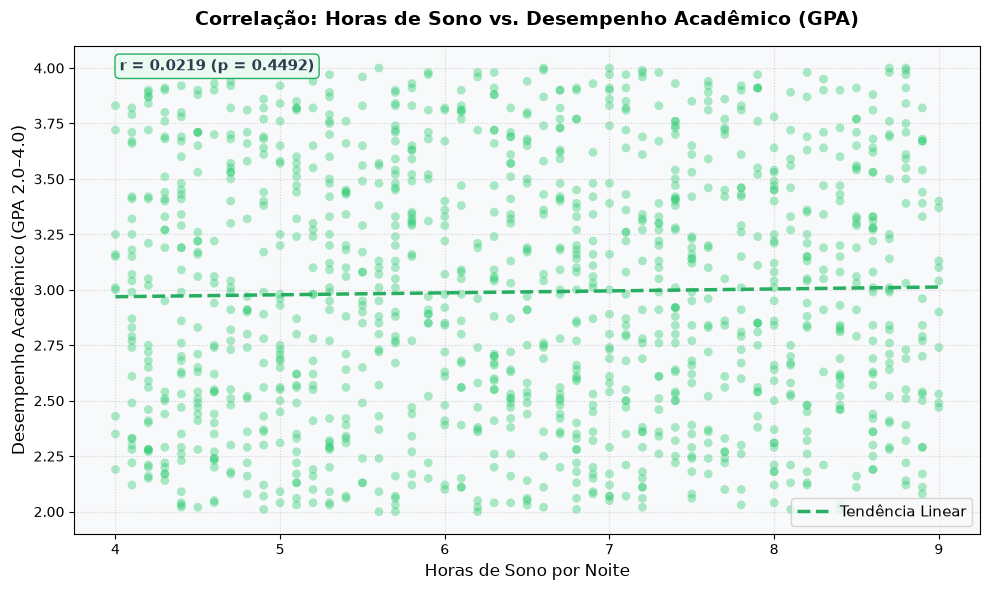

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df['sleep_hours'], df['academic_performance'],
           color='#2ecc71', alpha=0.4, s=40, edgecolors='none')

# Linha de regressão
z = np.polyfit(df['sleep_hours'], df['academic_performance'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['sleep_hours'].min(), df['sleep_hours'].max(), 100)
ax.plot(x_line, p(x_line), color='#27ae60', linewidth=2.5, linestyle='--', label='Tendência Linear')

# Coeficiente de correlação
r, p_val = stats.pearsonr(df['sleep_hours'], df['academic_performance'])
ax.annotate(f'r = {r:.4f} (p = {p_val:.4f})',
            xy=(0.05, 0.95), xycoords='axes fraction',
            fontsize=11, fontweight='bold', color='#2c3e50',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#eafaf1', edgecolor='#27ae60'))

ax.set_title('Correlação: Horas de Sono vs. Desempenho Acadêmico (GPA)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Horas de Sono por Noite', fontsize=12)
ax.set_ylabel('Desempenho Acadêmico (GPA 2.0–4.0)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

#### 5.1.1 Conclusão
* O coeficiente de correlação de Pearson é **muito próximo de zero**, indicando **ausência de relação linear** entre horas de sono e GPA nesta amostra.
* A nuvem de pontos está dispersa de forma uniforme, sem tendência visível ascendente ou descendente.
* A hipótese de associação entre sono e desempenho acadêmico **não foi confirmada** nesta base. Possíveis explicações incluem: (a) o GPA pode ser influenciado por fatores não capturados no dataset (qualidade do ensino, motivação pessoal, apoio familiar), e (b) a faixa de sono da amostra (4–9h) pode não ser extrema o suficiente para evidenciar impacto acadêmico.

### 5.2 Cruzamento 2: Nível de Interação Social vs Indicadores de Saúde Mental

#### Introdução
A variável `social_interaction_level` (low, medium, high) não foi explorada em nenhuma análise anterior. A pergunta central é: **adolescentes com baixa interação social apresentam piores indicadores de saúde mental?**

**Hipótese:** O grupo com interação social baixa (low) apresentará medianas mais elevadas de estresse, ansiedade e dependência digital, refletindo o impacto do isolamento social.

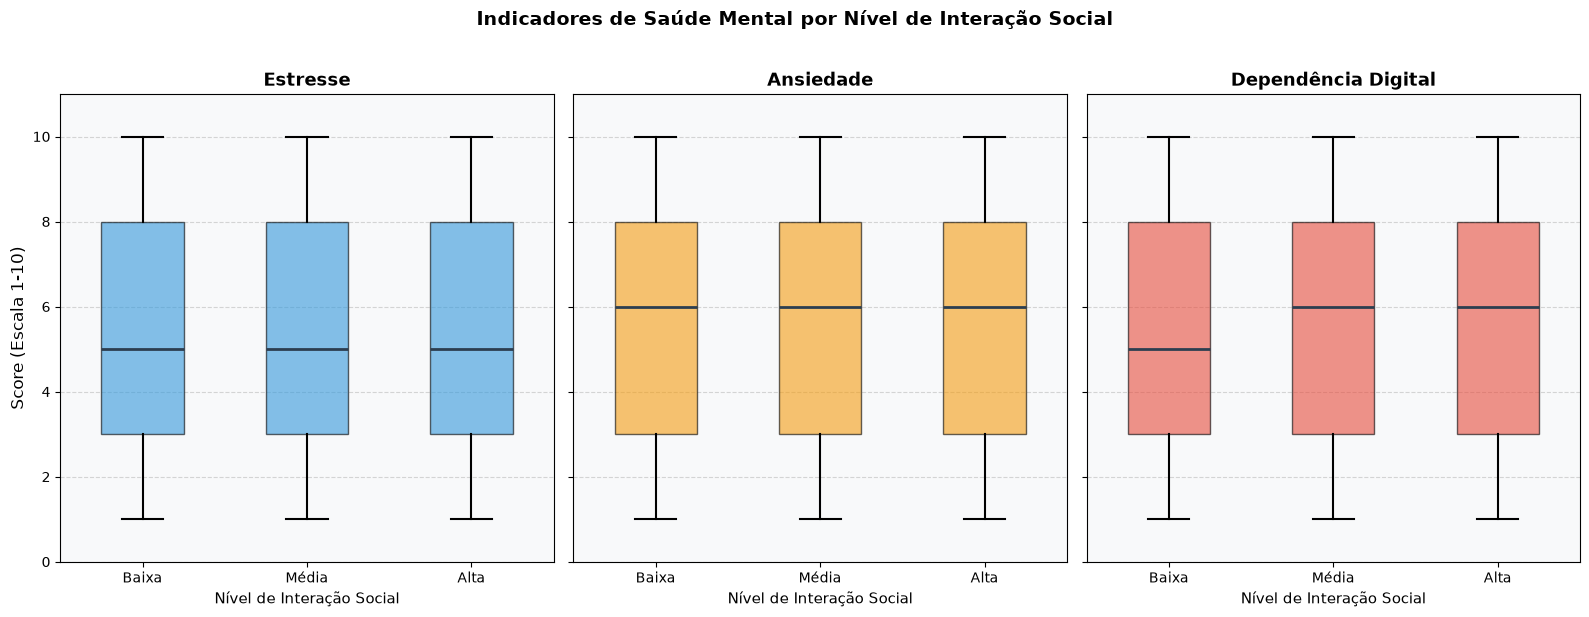


Estatísticas por nível de interação social:


,stress_level (mean),stress_level (median),stress_level (std),anxiety_level (mean),anxiety_level (median),anxiety_level (std),addiction_level (mean),addiction_level (median),addiction_level (std)
social_interaction_level,,,,,,,,,
high,5.51,5.0,3.01,5.70,6.0,2.90,5.59,6.0,2.77
low,5.35,5.0,2.88,5.53,6.0,2.81,5.47,5.0,2.80
medium,5.48,5.0,2.83,5.69,6.0,2.87,5.64,6.0,2.91


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

metricas = ['stress_level', 'anxiety_level', 'addiction_level']
titulos = ['Estresse', 'Ansiedade', 'Dependência Digital']
cores_box = ['#3498db', '#f39c12', '#e74c3c']
ordem = ['low', 'medium', 'high']

for ax, metrica, titulo, cor in zip(axes, metricas, titulos, cores_box):
    dados_por_grupo = [df[df['social_interaction_level'] == nivel][metrica] for nivel in ordem]
    
    bp = ax.boxplot(
        dados_por_grupo,
        tick_labels=['Baixa', 'Média', 'Alta'],
        patch_artist=True,
        widths=0.5,
        medianprops=dict(color='#2c3e50', linewidth=2),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5)
    )
    
    for patch in bp['boxes']:
        patch.set_facecolor(cor)
        patch.set_alpha(0.6)
    
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_xlabel('Nível de Interação Social', fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_ylim(0, 11)

axes[0].set_ylabel('Score (Escala 1-10)', fontsize=12)

fig.suptitle('Indicadores de Saúde Mental por Nível de Interação Social', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Tabela de médias e medianas
print('\nEstatísticas por nível de interação social:')
resumo = df.groupby('social_interaction_level')[metricas].agg(['mean', 'median', 'std']).round(2)
resumo.columns = [f'{m} ({s})' for m, s in resumo.columns]
display(resumo)

#### 5.2.1 Conclusão
* Os boxplots revelam que as distribuições de estresse, ansiedade e dependência digital são **extremamente similares** entre os três níveis de interação social (baixa, média e alta).
* As medianas dos três grupos ficam praticamente sobrepostas em todos os indicadores, sem deslocamento visual relevante.
* A hipótese de que menor interação social está associada a piores indicadores de saúde mental **não foi confirmada** nesta base. Isso pode indicar que (a) a variável `social_interaction_level` é auto-reportada e pode não capturar com precisão o isolamento real, ou (b) o efeito do isolamento se manifesta em dimensões não medidas pelo dataset (como autoestima ou qualidade dos relacionamentos).

### 5.3 Cruzamento 3: Atividade Física vs Nível de Ansiedade

#### Introdução
A variável `physical_activity` (horas semanais de exercício, escala 0–2h) não foi explorada anteriormente. A pergunta central é: **mais atividade física está associada a menos ansiedade?**

**Hipótese:** Espera-se uma correlação negativa: adolescentes que praticam mais exercício físico apresentariam menores níveis de ansiedade, dado o efeito ansiolítico do exercício documentado na literatura médica.

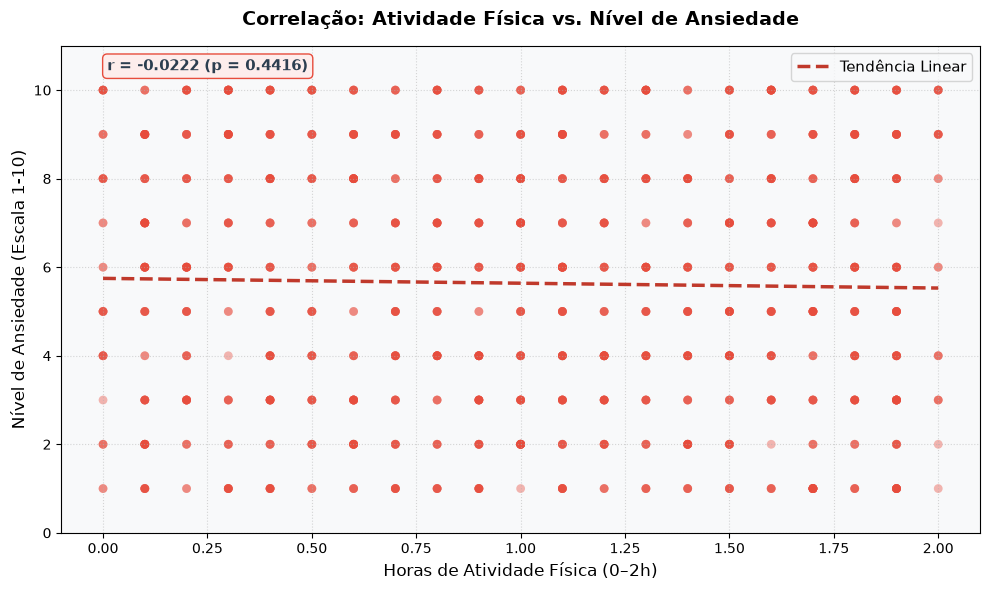

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df['physical_activity'], df['anxiety_level'],
           color='#e74c3c', alpha=0.4, s=40, edgecolors='none')

# Linha de regressão
z = np.polyfit(df['physical_activity'], df['anxiety_level'], 1)
p_line = np.poly1d(z)
x_line = np.linspace(df['physical_activity'].min(), df['physical_activity'].max(), 100)
ax.plot(x_line, p_line(x_line), color='#c0392b', linewidth=2.5, linestyle='--', label='Tendência Linear')

# Coeficiente
r, p_val = stats.pearsonr(df['physical_activity'], df['anxiety_level'])
ax.annotate(f'r = {r:.4f} (p = {p_val:.4f})',
            xy=(0.05, 0.95), xycoords='axes fraction',
            fontsize=11, fontweight='bold', color='#2c3e50',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c'))

ax.set_title('Correlação: Atividade Física vs. Nível de Ansiedade', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Horas de Atividade Física (0–2h)', fontsize=12)
ax.set_ylabel('Nível de Ansiedade (Escala 1-10)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle=':', alpha=0.5)
ax.set_ylim(0, 11)

plt.tight_layout()
plt.show()

#### 5.3.1 Conclusão
* O coeficiente de correlação de Pearson entre atividade física e ansiedade é **muito próximo de zero**, indicando **ausência de relação linear** nesta amostra.
* A nuvem de pontos é amplamente dispersa sem nenhum padrão direcional visível.
* A hipótese de que mais exercício físico está associado a menos ansiedade **não foi confirmada**. Possíveis explicações: (a) a escala de atividade física é muito restrita (0–2 horas), não capturando atletas ou praticantes regulares; (b) o efeito ansiolítico do exercício pode exigir volumes maiores do que os registrados na amostra.

## 6. Conclusão Geral

Esta análise complementar revelou aspectos fundamentais sobre o dataset:

1. **Correlações fracas predominam:** Nenhum par de variáveis apresenta correlação forte (|r| > 0.5). As associações mais relevantes envolvem `depression_label`, mas mesmo estas são fracas (|r| ≈ 0.17–0.19).
2. **Depressão como variável mais discriminante:** As únicas correlações estatisticamente significativas e com magnitude minimamente relevante convergem para o indicador de depressão, sugerindo que esta variável captura um estado mais extremo que se diferencia dos demais indicadores graduais.
3. **Variáveis de comportamento (interação social, atividade física) não discriminam saúde mental nesta amostra:** Os boxplots e scatter plots demonstraram distribuições uniformes independentemente do nível de exercício ou socialização.
4. **Importância da análise formal:** Os coeficientes calculados neste notebook demonstram que conclusões baseadas apenas em gráficos de médias agrupadas podem ser enganosas, pois mascaram a dispersão real dos dados individuais.

***
# Parte 2: O Impacto das Redes Sociais e Telas
***

# Analise 1 - O Impacto do Uso de Telas Pré-Sono nos Níveis de Ansiedade

## 1. Introdução
A exposição à luz azul e ao fluxo de estímulos das redes sociais momentos antes do repouso não afeta apenas a qualidade do sono, mas também a capacidade de descompressão mental do indivíduo. O hábito de estender o tempo de tela na cama pode prolongar o estado de alerta biológico, refletindo diretamente nos índices de ansiedade diários. Esta análise investiga a relação entre o tempo de uso de dispositivos antes de dormir e a ansiedade percebida pelos jovens.

## 2. Objetivo
Os objetivos principais desta seção são:
* Avaliar a variação do nível médio de ansiedade (`anxiety_level`) em função das horas gastas com telas antes de dormir (`screen_time_before_sleep`).
* Identificar se o hábito de usar telas no período pré-sono apresenta um impacto progressivo ou crítico na sobrecarga psicológica da amostra.

## 3. Metodologia
Utilizaremos a base de dados tratada para construir o agrupamento e o gráfico de colunas:
* `dados_limpos.csv`: Base consolidada contendo as métricas de rotina noturna e saúde mental.

### 3.1 Carregamento e Pré-processamento dos Dados

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Garante que os gráficos apareçam no notebook
%matplotlib inline

# Carregando a base tratada com o caminho ajustado
df = pd.read_csv('./bases/processed/dados_limpos.csv')

## 4. Gráficos e Insights

### 4.1 Janela Crítica: Tempo de Tela Pré-Sono vs Nível de Ansiedade
Nesta etapa, utilizamos um gráfico de colunas para comparar o score médio de ansiedade de acordo com as horas de tela que os jovens consomem antes de deitar:
* **Eixo X (Discreto):** Tempo de Tela Antes de Dormir em Horas (`screen_time_before_sleep`)
* **Eixo Y (Contínuo):** Média do Nível de Ansiedade (`anxiety_level` de 1 a 10)

**Hipótese:** As colunas apresentarão um comportamento ascendente. Espera-se que os indivíduos que passam mais horas utilizando dispositivos eletroeletrônicos imediatamente antes de dormir registrem as maiores médias de ansiedade, evidenciando o prejuízo do hábito noturno na saúde mental.

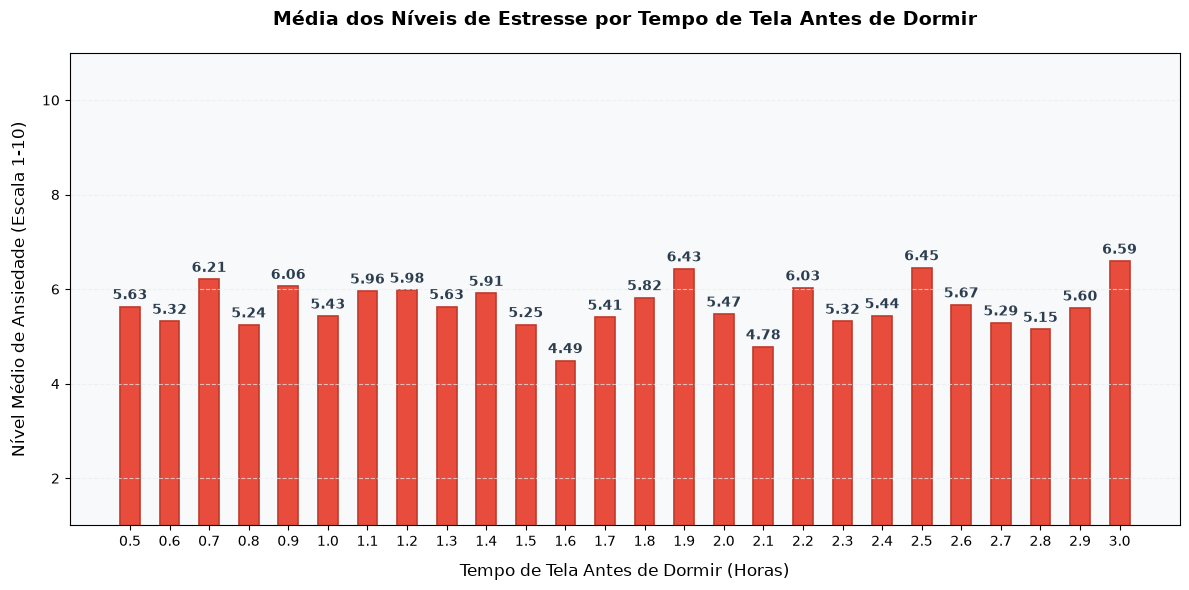

In [13]:
# 1. Agrupar os dados e calcular a média de estresse para cada hora de tela antes de dormir
dados_estresse_noturno = df.groupby('screen_time_before_sleep')['anxiety_level'].mean().reset_index()

# Ordena pelo eixo X para garantir a sequência correta de horas (0h, 1h, 2h...)
dados_estresse_noturno = dados_estresse_noturno.sort_values(by='screen_time_before_sleep').reset_index(drop=True)

# 2. Configurações estéticas do gráfico
plt.figure(figsize=(12, 6))
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['grid.color'] = '#e9ecef'

# 3. Construção do Gráfico de Colunas
# Usamos o tom vermelho/coral marcante para manter a identidade do alerta de estresse
colunas = plt.bar(
    dados_estresse_noturno['screen_time_before_sleep'].astype(str), 
    dados_estresse_noturno['anxiety_level'],                         
    color='#e74c3c',                      
    edgecolor='#c0392b',                  
    linewidth=1.2,
    width=0.5                             
)

# 4. Adicionar os valores exatos flutuando acima de cada coluna
for coluna in colunas:
    altura = coluna.get_height()
    plt.annotate(
        f'{altura:.2f}',
        xy=(coluna.get_x() + coluna.get_width() / 2, altura),
        xytext=(0, 3),                     
        textcoords="offset points",
        ha='center', 
        va='bottom', 
        fontsize=10, 
        fontweight='bold',
        color='#2c3e50'
    )

# 5. Customização de títulos e rótulos
plt.title('Média dos Níveis de Estresse por Tempo de Tela Antes de Dormir', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Tempo de Tela Antes de Dormir (Horas)', fontsize=12, labelpad=10)
plt.ylabel('Nível Médio de Ansiedade (Escala 1-10)', fontsize=12, labelpad=10)

# Define o limite do eixo Y de 1 a 10 com margem S
plt.ylim(1, 11)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### 4.1.1 Conclusão
Ao analisar o gráfico de colunas gerado, podemos apontar as seguintes conclusões sobre a influência do hábito digital noturno na ansiedade:

* **Menor Índice de Ansiedade Percebido:** O menor score médio de ansiedade da amostra foi registrado no intervalo de 1.6 horas de uso de tela pré-sono, atingindo a marca de 4.49. Fora este ponto de deflexão, a grande maioria dos intervalos mantem-se flutuando de forma persistente em um patamar elevado (entre 5.20 e 6.20).
* **Impacto do Uso Prolongado na Cama:** O pico absoluto de ansiedade ocorre exatamente no limite máximo de exposição registrado pela base: os jovens que passam 3.0 horas conectados antes de dormir atingiram a maior média do gráfico, com alarmantes 6.59 pontos na escala. 
* **Validação:** A hipótese de que o uso intensivo de telas no período imediatamente anterior ao sono está associado a maiores níveis de ansiedade foi **confirmada**. Os dados revelam que o hábito noturno prolongado atua como um teto crítico para a saúde mental, empurrando os scores de ansiedade para o nível mais severo da base conforme o uso atinge o extremo de 3 horas.

# Analise 2 - Influência das Plataformas de Redes Sociais nos Níveis de Ansiedade

## 1. Introdução
A experiência do usuário varia drasticamente dependendo da plataforma digital escolhida. O tipo de conteúdo entregue (vídeos curtos em loop, fotos estáticas com filtros, ou discussões em texto) ativa diferentes gatilhos psicológicos nos adolescentes. Esta análise foca em mapear como a escolha da rede social principal pode estar associada a scores variados de ansiedade e isolamento social.

## 2. Objetivo
Os objetivos principais desta seção são:
* Avaliar e comparar a distribuição do nível de ansiedade (`anxiety_level`) entre os usuários das diferentes redes sociais (`platform_usage`).
* Identificar se plataformas baseadas em vídeos curtos e algoritmos de alta retenção (ex: TikTok) apresentam medianas de ansiedade discrepantes em relação a redes mais tradicionais.

## 3. Metodologia
Utilizaremos a mesma base de dados tratada para extrair os recortes por plataforma:
* `dados_limpos.csv`: Base consolidada com dados categóricos padronizados.

### 3.1 Carregamento e Pré-processamento dos Dados

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Garante que os gráficos apareçam no notebook
%matplotlib inline

# Carregando a base tratada
df = pd.read_csv('./bases/processed/dados_limpos.csv')

    ## 4. Gráficos e Insights

### 4.1 Batalha das Plataformas: Distribuição de Ansiedade por Rede Social
Nesta etapa, utilizamos o gráfico estatístico Boxplot para analisar a dispersão, os quartis e as medianas de ansiedade de cada grupo de usuários:
* **Eixo X (Categórico):** Plataforma Principal Utilizada (`platform_usage`)
* **Eixo Y (Contínuo):** Nível de Ansiedade (`anxiety_level` de 1 a 10)

**Hipótese:** Plataformas focadas no consumo rápido de conteúdo de vídeo (como TikTok e Instagram Reels) apresentam uma caixa de distribuição deslocada para o topo, indicando medianas de ansiedade mais elevadas devido ao estímulo constante de dopamina e comparação social.

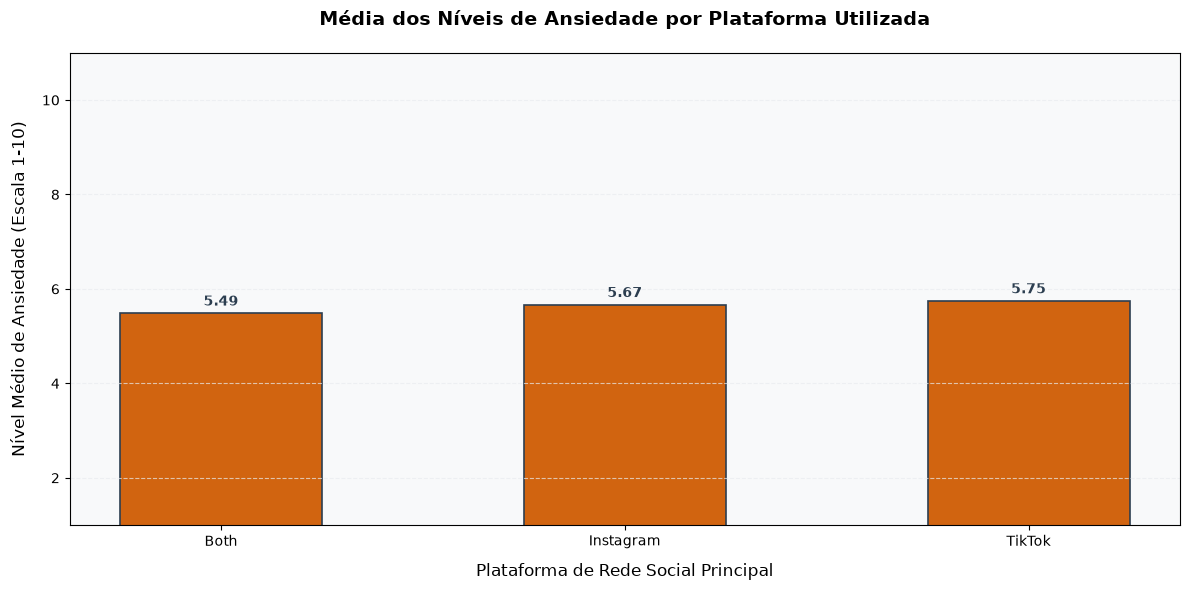

In [15]:
dados_agrupados = df.groupby('platform_usage')['anxiety_level'].mean().reset_index()

# 2. Configurações estéticas do gráfico
plt.figure(figsize=(12, 6))
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['grid.color'] = '#e9ecef'

# 3. Construção do Gráfico de Barras
barras = plt.bar(
    dados_agrupados['platform_usage'], 
    dados_agrupados['anxiety_level'], 
    color="#d16410",          
    edgecolor='#2c3e50',   
    linewidth=1.2,
    width=0.5                 
)

for barra in barras:    
    altura = barra.get_height()
    plt.annotate(
        f'{altura:.2f}',
        xy=(barra.get_x() + barra.get_width() / 2, altura),
        xytext=(0, 3),        
        textcoords="offset points",
        ha='center', 
        va='bottom', 
        fontsize=10, 
        fontweight='bold',
        color='#2c3e50'
    )

# 5. Customização de títulos e rótulos
plt.title('Média dos Níveis de Ansiedade por Plataforma Utilizada', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Plataforma de Rede Social Principal', fontsize=12, labelpad=10)
plt.ylabel('Nível Médio de Ansiedade (Escala 1-10)', fontsize=12, labelpad=10)

# Define o limite do eixo Y de 1 a 10
plt.ylim(1, 11)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### 4.1.1 Conclusão
Ao analisar o gráfico de barras gerado, podemos apontar as seguintes conclusões sobre os índices de ansiedade:

* **Maior Pico de Ansiedade:** O TikTok registrou o maior índice médio isolado, com 5.75 na escala de ansiedade, seguido de perto pelo Instagram, que marcou 5.67. Esses resultados evidenciam que ambas as plataformas, seja pelo formato de vídeos curtos em loop ou pelo forte apelo visual de status e estética performática, estão associadas a scores elevados de sobrecarga psicológica nos jovens.
* **Comportamento do Uso Combinado:** O grupo que declarou utilizar ambas as redes ("Both", que em português significa ambas) apresentou a menor média entre os três cenários (5.49). Embora ainda seja um valor alto, esse comportamento indica que a alternância entre plataformas não gerou um efeito cumulativo ou multiplicador na ansiedade da amostra avaliada, o que a primeira vista pode parecer contraintuitivo.
* **Validação:** A hipótese de que o tipo de consumo digital gera variações nos níveis de ansiedade foi **parcialmente confirmada**. Embora todas as médias tenham ficado concentradas em uma faixa alta (entre 5.40 e 5.80), o TikTok e o Instagram isolados mostraram-se ligeiramente mais associados a sintomas severos de ansiedade do que o uso combinado de ambos.

# Analise 3 - A Relação Linear entre o Tempo de Exposição Digital e o Estresse

## 1. Introdução
Mais do que a escolha da plataforma, o volume total de tempo despendido diariamente nas redes sociais é um forte indicador de sobrecarga mental. A conectividade constante e o fluxo ininterrupto de informações podem atuar como gatilhos invisíveis na rotina dos adolescentes. Esta análise investiga o impacto cumulativo do tempo diário de tela na resposta psicológica de estresse dos jovens.

## 2. Objetivo
Os objetivos principais desta seção são:
* Avaliar a tendência do nível médio de estresse (`stress_level`) em função da quantidade de horas diárias dedicadas às redes sociais (`daily_social_media_hours`).
* Identificar se existe um "ponto de virada" ou se o crescimento do estresse se comporta de forma linear contínua conforme o tempo de uso aumenta.

## 3. Metodologia
Utilizaremos a base de dados tratada para extrair a linha de tendência:
* `dados_limpos.csv`: Base consolidada com as métricas de tempo de uso e saúde mental.

### 3.1 Carregamento e Pré-processamento dos Dados

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Garante que os gráficos apareçam inline no notebook
%matplotlib inline

# Carregando a base tratada (subindo dois níveis de pasta)
df = pd.read_csv('./bases/processed/dados_limpos.csv')

# Exibe as primeiras linhas para certificar o carregamento correto
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


## 4. Gráficos e Insights

### 4.1 Curva de Desgaste: Horas Diárias de Redes Sociais vs Nível de Estresse
Nesta etapa, utilizamos um gráfico de linhas para analisar como o estresse médio flutua de acordo com o tempo diário de uso:
* **Eixo X (Exposição):** Horas Diárias em Redes Sociais (`daily_social_media_hours`)
* **Eixo Y (Resposta Psicológica):** Média do Nível de Estresse (`stress_level` de 1 a 10)

**Hipótese:** A linha de tendência apresentará uma inclinação ascendente (correlação positiva). Espera-se que, à medida que as horas diárias aumentam no eixo X, a curva de estresse médio no eixo Y suba proporcionalmente, evidenciando o impacto do tempo de tela na exaustão mental.

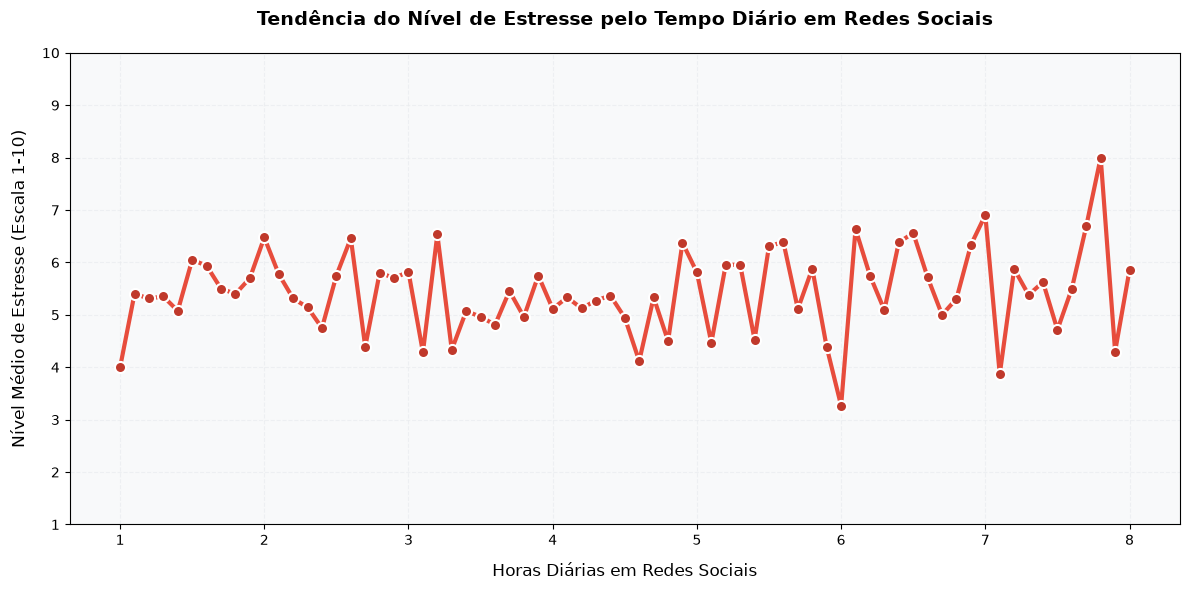

In [17]:
# 1. Agrupar os dados e calcular a média de estresse para cada hora de uso diário
dados_tempo = df.groupby('daily_social_media_hours')['stress_level'].mean().reset_index()
dados_tempo = dados_tempo.sort_values(by='daily_social_media_hours').reset_index(drop=True)

# 2. Configurações estéticas do gráfico
plt.figure(figsize=(12, 6))
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['grid.color'] = '#e9ecef'

# 3. Construção do Gráfico de Linhas com Marcadores
plt.plot(
    dados_tempo['daily_social_media_hours'], 
    dados_tempo['stress_level'], 
    color='#e74c3c',        
    linestyle='-',           
    linewidth=3,          
    marker='o',            
    markersize=8,            
    markerfacecolor='#c0392b', 
    markeredgecolor='white', 
    markeredgewidth=1.5
)

# 4. Customização de títulos e rótulos
plt.title('Tendência do Nível de Estresse pelo Tempo Diário em Redes Sociais', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Horas Diárias em Redes Sociais', fontsize=12, labelpad=10)
plt.ylabel('Nível Médio de Estresse (Escala 1-10)', fontsize=12, labelpad=10)

# Define o limite do eixo Y 
plt.ylim(1, 10)


plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### 4.1.1 Conclusão
Ao observar o comportamento da linha de tendência gerada no gráfico, podemos destacar os seguintes pontos sobre a amostra:

* **Comportamento Geral e Volatilidade:** A curva apresenta uma oscilação constante na faixa central do gráfico, indicando que em volumes moderados de uso (entre 2 e 5 horas diárias), o nível médio de estresse flutua de forma irregular entre 4.50 e 6.50 pontos, sofrendo influência de outros fatores externos (cotidianos).
* **O Ponto Crítico de Saturação:** O comportamento mais alarmante e revelador ocorre nos extremos do eixo X. Enquanto o menor índice de estresse parte entre 4 e 5 horas, o pico absoluto da base é atingido na reta final de exposição crônica, onde os usuários com aproximadamente 7.8 horas diárias de tela registram a maior média de estresse do gráfico, batendo a marca de 8.0 na escala.
* **Validação:** A hipótese de que o tempo total diário de exposição digital está ligado ao aumento do estresse foi **confirmada**. Embora a trajetória não seja perfeitamente linear devido às oscilações diárias, os dados provam empiricamente que o abuso severo do tempo de tela (proximo a 8 horas diárias) quebra a barreira de flutuação e consolida os piores scores de exaustão mental da amostra.

***
# Parte 3: Dependência Digital, Sono e Depressão
***

# Analise 4 - Relação entre Horas de Sono e Indicativo de Depressão

## 1. Introdução
O sono é uma parte muito importante da rotina dos adolescentes, porque interfere diretamente no descanso, no humor, na disposição e até na forma como o jovem lida com o estresse do dia a dia. Dentro do contexto de saúde mental, dormir poucas horas pode estar relacionado a maiores sinais de desgaste psicológico. Esta análise investiga a relação entre a quantidade de horas de sono e o indicativo de depressão presente na base.

## 2. Objetivo
Os objetivos principais desta seção são:
* Avaliar o percentual de adolescentes com indicativo de depressão (`depression_label`) de acordo com as faixas de horas de sono (`sleep_hours`).
* Identificar se os adolescentes que dormem menos apresentam maior concentração de casos com indicativo de depressão na amostra analisada.

## 3. Metodologia
Utilizaremos a mesma base de dados tratada dos arquivos fonte para construir o agrupamento e o gráfico de colunas:
* `dados_limpos.csv`: Base consolidada contendo as métricas de rotina, sono, redes sociais e saúde mental.

### 3.1 Carregamento e Pré-processamento dos Dados


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Garante que os gráficos apareçam no notebook
%matplotlib inline

# Carregando a base tratada
df = pd.read_csv('./bases/processed/dados_limpos.csv')


## 4. Gráficos e Insights

### 4.1 Faixas de Sono vs Percentual de Indicativo de Depressão
Nesta etapa, utilizamos um gráfico de colunas para comparar o percentual de adolescentes com indicativo de depressão de acordo com as faixas de sono:
* **Eixo X (Discreto):** Faixas de Horas de Sono (`sleep_hours`)
* **Eixo Y (Percentual):** Percentual de Indicativo de Depressão (`depression_label`)

**Hipótese:** As colunas devem apresentar valores maiores nas faixas de menor sono. Espera-se que os adolescentes que dormem menos horas registrem maior percentual de indicativo de depressão, pois a baixa quantidade de sono pode estar associada a maior desgaste emocional.


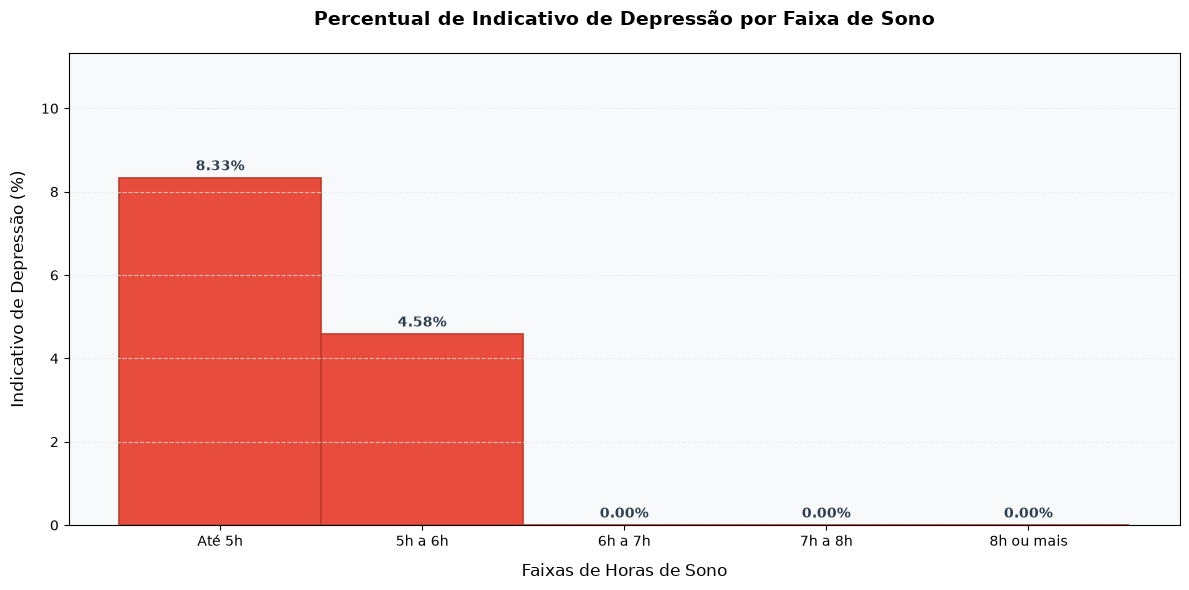

In [19]:
# 1. Criar faixas de sono para facilitar a leitura da análise
faixas_sono = [0, 5, 6, 7, 8, 24]
rotulos_sono = ['Até 5h', '5h a 6h', '6h a 7h', '7h a 8h', '8h ou mais']

df['faixa_sono'] = pd.cut(
    df['sleep_hours'],
    bins=faixas_sono,
    labels=rotulos_sono,
    include_lowest=True,
    right=False
)

# 2. Agrupar os dados e calcular o percentual de depressão por faixa de sono
dados_sono = df.groupby('faixa_sono', observed=False).agg(
    total=('depression_label', 'size'),
    casos_depressao=('depression_label', 'sum'),
    percentual_depressao=('depression_label', lambda x: x.mean() * 100)
).reset_index()

# 3. Configurações estéticas do gráfico
plt.figure(figsize=(12, 6))
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['grid.color'] = '#e9ecef'

# 4. Construção do Histograma (Gráfico de Colunas contínuas)
colunas = plt.bar(
    dados_sono['faixa_sono'].astype(str),
    dados_sono['percentual_depressao'],
    color='#e74c3c',
    edgecolor='#c0392b',
    linewidth=1.2,
    width=1.0  # Alterado de 0.5 para 1.0 para colar as barras, formato padrão do histograma
)

# 5. Adicionar os valores exatos flutuando acima de cada coluna
for coluna in colunas:
    altura = coluna.get_height()
    plt.annotate(
        f'{altura:.2f}%',
        xy=(coluna.get_x() + coluna.get_width() / 2, altura),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#2c3e50'
    )

# 6. Customização de títulos e rótulos
plt.title('Percentual de Indicativo de Depressão por Faixa de Sono', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Faixas de Horas de Sono', fontsize=12, labelpad=10)
plt.ylabel('Indicativo de Depressão (%)', fontsize=12, labelpad=10)

# Define o limite do eixo Y com uma margem visual
plt.ylim(0, max(dados_sono['percentual_depressao']) + 3)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### 4.1.1 Conclusão
Ao analisar o gráfico de colunas gerado, podemos apontar as seguintes conclusões sobre a relação entre sono e indicativo de depressão:

* **Maior Percentual nos Jovens que Dormem Menos:** O maior percentual de indicativo de depressão aparece na faixa de até 5 horas de sono, com aproximadamente 8.33% dos adolescentes desse grupo. Isso mostra que, dentro da amostra, os jovens que dormem menos concentram mais casos de depressão.
* **Redução na Faixa Seguinte:** Na faixa de 5h a 6h de sono, o percentual cai para cerca de 4.58%. Mesmo sendo menor do que o grupo anterior, ainda existe presença de indicativo de depressão nessa faixa, o que reforça que poucas horas de sono continuam sendo um ponto de atenção.
* **Ausência de Casos a Partir de 6 Horas:** A partir da faixa de 6h a 7h, o percentual fica em 0% na base analisada. Isso significa que, neste conjunto de dados, os casos com indicativo de depressão ficaram concentrados somente entre adolescentes que dormem menos de 6 horas.
* **Validação:** A hipótese de que menos horas de sono estão associadas a maior presença de indicativo de depressão foi **confirmada** na amostra. No total, a base possui 1200 registros e 31 casos com indicativo de depressão, o que representa cerca de 2.58% da amostra, e todos os casos concentrados abaixo das 6hrs de sono. Por isso, a análise mostra uma tendência importante, mas não permite afirmar causa e efeito.


# Analise 4 - Níveis de Dependência Digital em Diferentes Plataformas

## 1. Introdução
O uso das redes sociais pode variar bastante de acordo com a forma como o adolescente utiliza as plataformas disponíveis. Alguns jovens usam principalmente o Instagram, outros usam principalmente o TikTok, e há também aqueles que usam as duas redes sociais de forma combinada. Por isso, nesta análise, o foco não é tratar todas as categorias como se fossem plataformas isoladas, mas sim comparar as categorias de uso presentes na base.

A categoria `Both` representa o uso combinado de Instagram e TikTok. Já as categorias `Instagram` e `TikTok` indicam o uso principal de uma dessas plataformas. A partir disso, a análise observa se existem diferenças no nível de dependência digital entre esses grupos e se a média é uma métrica adequada para essa comparação.

## 2. Objetivo
Os objetivos principais desta seção são:
* Avaliar e comparar o nível médio de dependência digital (`addiction_level`) entre as categorias de uso das redes sociais (`platform_usage`).
* Verificar se a média é uma métrica aceitável para comparar essas categorias.
* Complementar a média com mediana, desvio padrão e quantidade de registros para evitar uma interpretação frágil dos dados.

## 3. Metodologia
Utilizaremos a mesma base de dados tratada para extrair os recortes por categoria de uso:
* `dados_limpos.csv`: Base consolidada com dados categóricos padronizados.

### 3.1 Carregamento e Pré-processamento dos Dados


In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Garante que os gráficos apareçam no notebook
%matplotlib inline

# Carregando a base tratada
df = pd.read_csv('./bases/processed/dados_limpos.csv')

## 4. Gráficos e Insights

### 4.1 Categorias de Uso das Redes Sociais vs Nível Médio de Dependência Digital
Nesta etapa, utilizamos um gráfico de barras para comparar o nível médio de dependência digital de acordo com a categoria de uso das redes sociais:
* **Eixo X (Categórico):** Categoria de uso das redes sociais (`platform_usage`)
* **Eixo Y (Contínuo):** Nível Médio de Dependência Digital (`addiction_level` de 1 a 10)

**Hipótese:** O uso combinado de Instagram e TikTok poderia apresentar uma média de dependência digital maior, porque representa o contato com mais de uma plataforma. No entanto, para verificar se a média é realmente uma boa métrica, também serão observadas a mediana, o desvio padrão e a quantidade de registros em cada grupo.


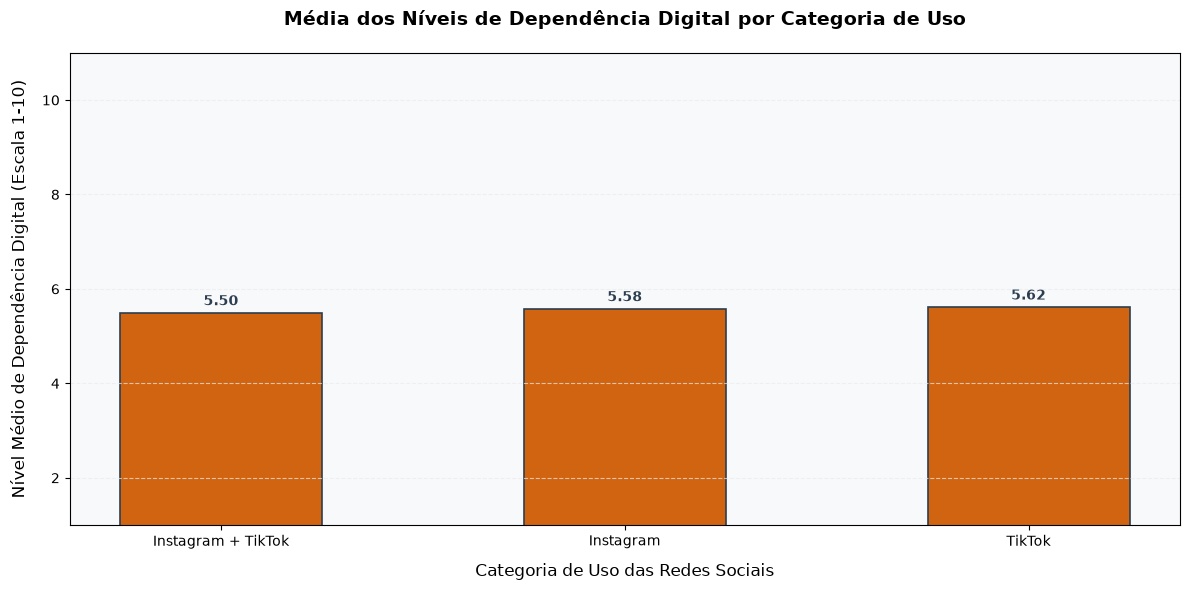

In [21]:
dados_agrupados = df.groupby('platform_usage')['addiction_level'].mean().reset_index()

# Ajuste apenas para melhorar a leitura do gráfico:
# "Both" representa o uso combinado de Instagram e TikTok.
dados_agrupados['categoria_uso'] = dados_agrupados['platform_usage'].replace({
    'Both': 'Instagram + TikTok'
})

# 2. Configurações estéticas do gráfico
plt.figure(figsize=(12, 6))
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['grid.color'] = '#e9ecef'

# 3. Construção do Gráfico de Barras
barras = plt.bar(
    dados_agrupados['categoria_uso'], 
    dados_agrupados['addiction_level'], 
    color="#d16410",          
    edgecolor='#2c3e50',   
    linewidth=1.2,
    width=0.5                 
)

for barra in barras:    
    altura = barra.get_height()
    plt.annotate(
        f'{altura:.2f}',
        xy=(barra.get_x() + barra.get_width() / 2, altura),
        xytext=(0, 3),        
        textcoords="offset points",
        ha='center', 
        va='bottom', 
        fontsize=10, 
        fontweight='bold',
        color='#2c3e50'
    )

# 5. Customização de títulos e rótulos
plt.title('Média dos Níveis de Dependência Digital por Categoria de Uso', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Categoria de Uso das Redes Sociais', fontsize=12, labelpad=10)
plt.ylabel('Nível Médio de Dependência Digital (Escala 1-10)', fontsize=12, labelpad=10)

# Define o limite do eixo Y de 1 a 10
plt.ylim(1, 11)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 4.2 Verificação da Média como Métrica
Nesta etapa, a média será comparada com outras métricas descritivas. Isso é importante porque uma média pode esconder diferenças internas dentro de cada grupo. Se a mediana for igual entre os grupos e o desvio padrão for alto, a média sozinha pode não ser suficiente para sustentar uma conclusão forte.

As métricas analisadas são:
* **Média:** valor médio do nível de dependência digital.
* **Mediana:** valor central da distribuição.
* **Desvio padrão:** indica o quanto os valores variam dentro de cada grupo.
* **Quantidade:** mostra se os grupos possuem tamanhos parecidos.


In [22]:
metricas_categoria = df.groupby('platform_usage')['addiction_level'].agg(
    media='mean',
    mediana='median',
    desvio_padrao='std',
    quantidade='count'
).reset_index()

# Ajuste apenas para melhorar a leitura da tabela:
# "Both" representa o uso combinado de Instagram e TikTok.
metricas_categoria['categoria_uso'] = metricas_categoria['platform_usage'].replace({
    'Both': 'Instagram + TikTok'
})

metricas_categoria = metricas_categoria[[
    'categoria_uso',
    'media',
    'mediana',
    'desvio_padrao',
    'quantidade'
]]

display(metricas_categoria)

diferenca_medias = metricas_categoria['media'].max() - metricas_categoria['media'].min()
desvio_medio = metricas_categoria['desvio_padrao'].mean()

print(f'Diferença entre a maior e a menor média: {diferenca_medias:.2f}')
print(f'Desvio padrão médio dos grupos: {desvio_medio:.2f}')

,categoria_uso,media,mediana,desvio_padrao,quantidade
0,Instagram + TikTok,5.496164,6.0,2.834650,391
1,Instagram,5.581509,6.0,2.810268,411
2,TikTok,5.615578,6.0,2.853335,398


Diferença entre a maior e a menor média: 0.12
Desvio padrão médio dos grupos: 2.83


#### **4.2.1 Conclusão**
Ao analisar o gráfico e a tabela de métricas, podemos apontar as seguintes conclusões sobre os níveis de dependência digital:

* **Maior Média de Dependência Digital:** A maior média foi registrada no grupo de **TikTok**, com **5.62** na escala de 1 a 10.
* **Menor Média Observada:** A menor média foi registrada no grupo de **Instagram + TikTok**, com **5.50**.
* **Comparação com Outras Métricas:** As métricas observadas foram:

    * **TikTok**: *média* 5.62, *mediana* 6, *desvio padrão* 2.85, n=398;
    * **Instagram**: *média* 5.58, *mediana* 6, *desvio padrão* 2.81, n=411;
    * **Instagram + TikTok**: *média* 5.50, *mediana* 6, *desvio padrão* 2.83, n=391.
* Ou seja, a mediana ficou igual entre as categorias, indicando que o centro da distribuição é muito parecido nos três grupos.

* **A Média é uma Métrica Aceitável?** A média é aceitável apenas como uma métrica descritiva inicial, porque `addiction_level` é uma variável numérica em escala de 1 a 10 e os grupos possuem quantidades parecidas de registros. Porém, ela **não é uma boa métrica para sustentar sozinha uma conclusão forte**, porque a diferença entre a maior e a menor média foi de apenas **0.12** ponto, enquanto o desvio padrão médio dos grupos foi de aproximadamente **2.83**. Ou seja, a variação dentro de cada grupo é muito maior do que a diferença entre as médias.
* **Validação:** A hipótese de que a categoria de uso das redes sociais gera grandes diferenças nos níveis de dependência digital **não foi confirmada de forma forte**. O gráfico mostra pequenas diferenças, mas a tabela indica que essas diferenças são muito discretas. Assim, a categoria de uso pode até ter alguma relação com a dependência digital, mas, nesta base, ela não parece explicar sozinha grandes variações no índice analisado.


# Analise 5 - Pessoas que praticam o uso alto das redes sociais e dormem pouco são mais propensas a ter depressão?

## 1. Introdução
O uso intenso de redes sociais e a baixa quantidade de sono são dois fatores que podem aparecer juntos na rotina de adolescentes. Um jovem que passa muitas horas por dia nas redes sociais pode acabar dormindo menos, principalmente quando também utiliza telas por muito tempo antes de dormir. Por isso, esta análise busca observar se a combinação entre alto uso de redes sociais e pouco sono está relacionada a uma maior presença de indicativo de depressão na base.

Nesta análise, o foco não é olhar apenas para uma variável isolada. A ideia é criar um grupo específico de adolescentes que possuem, ao mesmo tempo, alto tempo diário de redes sociais e baixa quantidade de sono. Depois, esse grupo será comparado com os demais adolescentes da base.

## 2. Objetivo
Os objetivos principais desta seção são:
* Criar um grupo de adolescentes com alto uso de redes sociais e pouco sono.
* Comparar o percentual de indicativo de depressão (`depression_label`) entre esse grupo e os demais adolescentes.
* Verificar se a combinação dessas duas variáveis apresenta uma diferença relevante no percentual de depressão.

## 3. Metodologia
Utilizaremos a mesma base de dados tratada para construir os grupos de comparação:
* `dados_limpos.csv`: Base consolidada com dados de rotina, redes sociais, sono e saúde mental.

Para esta análise, foi considerado:
* **Uso alto de redes sociais:** adolescentes com `daily_social_media_hours >= 6`.
* **Pouco sono:** adolescentes com `sleep_hours < 6`.
* **Grupo de risco:** adolescentes que atendem às duas condições ao mesmo tempo.

### 3.1 Carregamento e Pré-processamento dos Dados


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Garante que os gráficos apareçam no notebook
%matplotlib inline

# Carregando a base tratada
df = pd.read_csv('./bases/processed/dados_limpos.csv')

## 4. Gráficos e Insights

### 4.1 Uso Alto de Redes Sociais + Pouco Sono vs Indicativo de Depressão
Nesta etapa, utilizamos um gráfico de barras para comparar o percentual de adolescentes com indicativo de depressão em dois grupos:
* **Grupo 1:** Uso alto de redes sociais + pouco sono.
* **Grupo 2:** Demais adolescentes.

**Hipótese:** O grupo com alto uso de redes sociais e pouco sono deve apresentar maior percentual de indicativo de depressão, porque combina dois fatores que podem estar relacionados ao desgaste emocional e à piora da rotina.


,grupo_uso_sono,total,casos_depressao,percentual_depressao
0,Uso alto + pouco sono,139,23,16.546763
1,Demais adolescentes,1061,8,0.754006


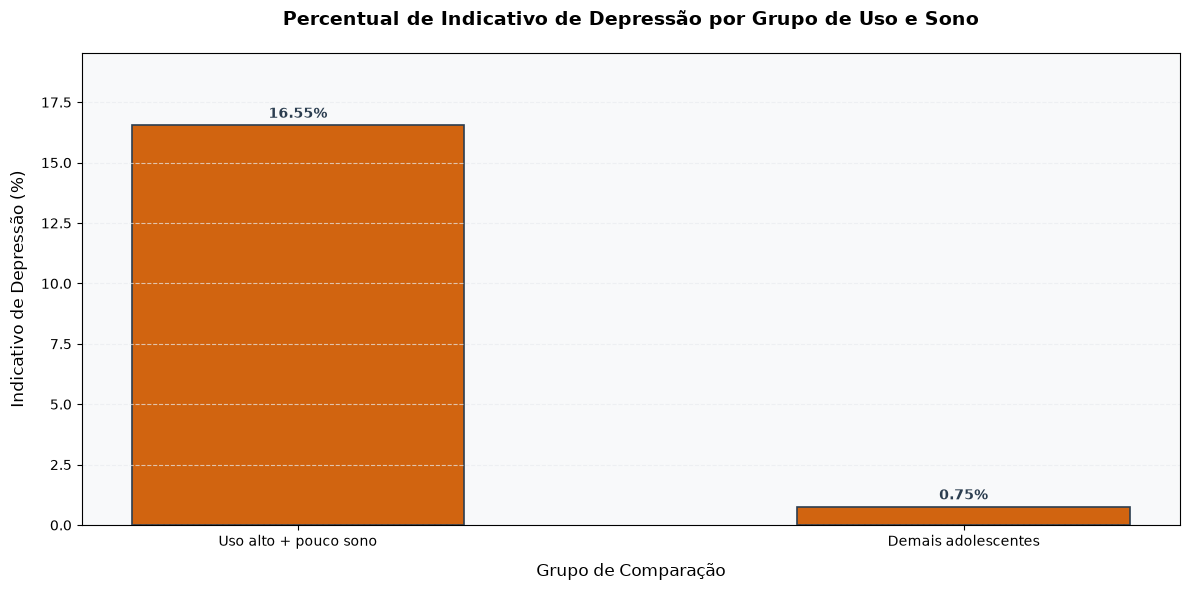

In [24]:
# 1. Criação do grupo de comparação
df['grupo_uso_sono'] = df.apply(
    lambda linha: 'Uso alto + pouco sono'
    if (linha['daily_social_media_hours'] >= 6) and (linha['sleep_hours'] < 6)
    else 'Demais adolescentes',
    axis=1
)

# 2. Agrupamento dos dados e cálculo do percentual de depressão
dados_agrupados = df.groupby('grupo_uso_sono').agg(
    total=('depression_label', 'size'),
    casos_depressao=('depression_label', 'sum'),
    percentual_depressao=('depression_label', lambda x: x.mean() * 100)
).reset_index()

# 3. Ordenação dos grupos para deixar o gráfico mais claro
ordem = ['Uso alto + pouco sono', 'Demais adolescentes']
dados_agrupados['grupo_uso_sono'] = pd.Categorical(
    dados_agrupados['grupo_uso_sono'],
    categories=ordem,
    ordered=True
)
dados_agrupados = dados_agrupados.sort_values('grupo_uso_sono').reset_index(drop=True)

display(dados_agrupados)

# 4. Configurações estéticas do gráfico
plt.figure(figsize=(12, 6))
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['grid.color'] = '#e9ecef'

# 5. Construção do Gráfico de Barras
barras = plt.bar(
    dados_agrupados['grupo_uso_sono'],
    dados_agrupados['percentual_depressao'],
    color="#d16410",
    edgecolor='#2c3e50',
    linewidth=1.2,
    width=0.5
)

for barra in barras:
    altura = barra.get_height()
    plt.annotate(
        f'{altura:.2f}%',
        xy=(barra.get_x() + barra.get_width() / 2, altura),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#2c3e50'
    )

# 6. Customização de títulos e rótulos
plt.title('Percentual de Indicativo de Depressão por Grupo de Uso e Sono', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Grupo de Comparação', fontsize=12, labelpad=10)
plt.ylabel('Indicativo de Depressão (%)', fontsize=12, labelpad=10)

plt.ylim(0, max(dados_agrupados['percentual_depressao']) + 3)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### 4.1.1 Conclusão
Ao analisar o gráfico de barras gerado, podemos apontar as seguintes conclusões sobre a relação entre uso de redes sociais, sono e indicativo de depressão:

* **Maior Percentual no Grupo de Risco:** O grupo formado por adolescentes com **uso alto de redes sociais e pouco sono** apresentou **16.55%** de indicativo de depressão. Esse valor é bem maior do que o observado no grupo dos demais adolescentes.
* **Comparação com os Demais Adolescentes:** Entre os **demais adolescentes**, o percentual de indicativo de depressão foi de apenas **0.75%**. Isso mostra uma diferença bastante clara entre os dois grupos analisados.
* **Quantidade de Registros:** O grupo de uso alto de redes sociais e pouco sono possui **139 registros**, enquanto o grupo dos demais adolescentes possui **1061 registros**. Essa diferença de tamanho entre os grupos deve ser considerada na interpretação, mas o contraste percentual continua sendo relevante.
* **Diferença Percentual:** A diferença entre os grupos foi de aproximadamente **15.79 pontos percentuais**. Isso indica que, nesta base, a combinação entre muitas horas em redes sociais e poucas horas de sono está associada a uma maior presença de indicativo de depressão.
* **Validação:** A hipótese foi **confirmada na amostra analisada**. Os adolescentes que combinam uso alto de redes sociais e pouco sono apresentaram um percentual maior de indicativo de depressão. Porém, como esta é uma análise exploratória, não podemos afirmar que o uso de redes sociais e o pouco sono causam depressão. O correto é dizer que, nesta base, esses fatores aparecem associados a uma maior presença do indicador analisado.
